In [2]:
! pip install pandas

  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 10.4 MB/s eta 0:00:00a 0:00:01
Using cached pytz-2025.2-py2.py3-none-any.whl (509 kB)


# Panstar and Decam to do matching

In [25]:
"""
Program to cross-match SExtractor catalogs with Pan-STARRS DR1.
"""

import numpy as np
import pandas as pd
import astropy.units as u
from astropy.coordinates import SkyCoord
from typing import List, Tuple
from pandas import DataFrame

### ----------- SExtractor Reader Functions ----------- ###

def _get_column_names(read_line_object: List) -> List:
    """Reads the header info of the SExtractor catalog."""
    header = [line.split()[2] for line in read_line_object if line[0] == '#']
    return header

def _get_rows(read_line_object: List) -> List:
    """Reads the data rows from the SExtractor catalog."""
    data = [list(map(float, line.split())) for line in read_line_object if line[0] != '#']
    return data

def split_names_and_data(read_line_object: List) -> Tuple[List, List]:
    """Splits header and data rows."""
    header = _get_column_names(read_line_object)
    data = _get_rows(read_line_object)
    return header, data

def read_cat(sextractor_catalog: str) -> DataFrame:
    """Reads in a SExtractor catalog file and returns a DataFrame."""
    with open(sextractor_catalog, encoding='utf8') as file:
        lines = file.readlines()
    column_names, data = split_names_and_data(lines)
    data_frame = DataFrame(data, columns=column_names)
    return data_frame

### ----------- Cross-match Function ----------- ###

def cross_match(ra_new: np.array, dec_new: np.array, ra_catalog: np.array, dec_catalog: np.array):
    """Cross-match two sets of sky coordinates using astropy."""
    c_new = SkyCoord(ra=ra_new * u.deg, dec=dec_new * u.deg)
    c_catalog = SkyCoord(ra=ra_catalog * u.deg, dec=dec_catalog * u.deg)
    idx, d2d, _ = c_new.match_to_catalog_sky(c_catalog)
    print(d2d)
    max_separation = 1.0 * u.arcsec
    separation_constraint = d2d < max_separation
    matched_idx_decam = np.where(separation_constraint)[0]
    matched_idx_panstars = idx[separation_constraint]
    return matched_idx_decam, matched_idx_panstars

### ----------- CatalogMatcher Class ----------- ###

class CatalogMatcher:
    """Handles matching SExtractor catalogs with Pan-STARRS DR1."""

    def __init__(self, sextractor_cat_path: str, panstarrs_csv_path: str):
        # Load SExtractor catalog
        self.sextractor_catalog = read_cat(sextractor_cat_path)

        # Load Pan-STARRS DR1 catalog
        self.panstarrs_catalog = pd.read_csv(panstarrs_csv_path)

    def match_catalogs(self):
        """Cross-match SExtractor and Pan-STARRS DR1 catalogs based on RA/Dec."""
        ra_decam = np.array(self.sextractor_catalog['ALPHAPEAK_J2000'])
        dec_decam = np.array(self.sextractor_catalog['DELTAPEAK_J2000'])

        ra_panstars = np.array(self.panstarrs_catalog['raMean'])
        dec_panstars = np.array(self.panstarrs_catalog['decMean'])

        idx_decam, idx_panstars = cross_match(ra_decam, dec_decam, ra_panstars, dec_panstars)

        matched_decam = self.sextractor_catalog.iloc[idx_decam].reset_index(drop=True)
        matched_panstars = self.panstarrs_catalog.iloc[idx_panstars].reset_index(drop=True)

        return matched_decam, matched_panstars

    def save_matches(self, matched_decam, matched_panstars, decam_out='/Users/aishwarya/Documents/Lyman_alpha/CAT/cat/matched_decam_zdepth.cat', pan_out='/Users/aishwarya/Documents/Lyman_alpha/CAT/cat/matched_panstars_zdepth.csv'):
        """Save matched catalogs to disk."""
        matched_decam.to_csv(decam_out, index=False)
        matched_panstars.to_csv(pan_out, index=False)
        print(f"Saved matched DECam to: {decam_out}")
        print(f"Saved matched Pan-STARRS to: {pan_out}")

### ----------- Script Entry Point ----------- ###

if __name__ == '__main__':
    # Paths to your input files
    SEX_CATALOG_PATH = '/Users/aishwarya/Documents/Lyman_alpha/CAT/cat/z_band_depth.cat'
    PANSTARRS_PATH = '/Users/aishwarya/Documents/Lyman_alpha/CAT/pannstar.csv'

    # Instantiate and match
    matcher = CatalogMatcher(SEX_CATALOG_PATH, PANSTARRS_PATH)
    matched_decam, matched_panstars = matcher.match_catalogs()

    # Save matched outputs
    matcher.save_matches(matched_decam, matched_panstars)


[0d01m08.25164353s 0d04m09.84613358s 0d11m01.93238713s ...
 1d18m11.40741739s 1d12m42.23211602s 1d31m30.20873587s]
Saved matched DECam to: /Users/aishwarya/Documents/Lyman_alpha/CAT/cat/matched_decam_zdepth.cat
Saved matched Pan-STARRS to: /Users/aishwarya/Documents/Lyman_alpha/CAT/cat/matched_panstars_zdepth.csv


# TO CHECK what is the offset of RA and DEC

In [112]:
"""
Program to cross-match SExtractor catalogs with Pan-STARRS DR1
and compute the median angular offset between matched sources.
"""

import numpy as np
import pandas as pd
import astropy.units as u
from astropy.coordinates import SkyCoord
from typing import List, Tuple
from pandas import DataFrame

### ----------- SExtractor  Functions ----------- ###

def _get_column_names(read_line_object: List) -> List:
    """Reads the header info of the SExtractor catalog."""
    header = [line.split()[2] for line in read_line_object if line[0] == '#']
    return header

def _get_rows(read_line_object: List) -> List:
    """Reads the data rows from the SExtractor catalog."""
    data = [list(map(float, line.strip().split())) for line in read_line_object if line[0] != '#']
    return data

def split_names_and_data(read_line_object: List) -> Tuple[List, List]:
    """Splits header and data rows."""
    header = _get_column_names(read_line_object)
    data = _get_rows(read_line_object)
    return header, data

def read_cat(sextractor_catalog: str) -> DataFrame:
    """Reads in a SExtractor catalog file and returns a DataFrame."""
    with open(sextractor_catalog, encoding='utf8') as file:
        lines = file.readlines()
    column_names, data = split_names_and_data(lines)
    data_frame = DataFrame(data, columns=column_names)
    return data_frame

### ----------- Cross-match Function ----------- ###

def cross_match(ra_new: np.array, dec_new: np.array, ra_catalog: np.array, dec_catalog: np.array):
    """Cross-match two sets of sky coordinates using astropy."""
    c_new = SkyCoord(ra=ra_new * u.deg, dec=dec_new * u.deg)
    c_catalog = SkyCoord(ra=ra_catalog * u.deg, dec=dec_catalog * u.deg)
    idx, d2d, _ = c_new.match_to_catalog_sky(c_catalog)
    max_separation = 1.0 * u.arcsec
    separation_constraint = d2d < max_separation
    matched_idx_decam = np.where(separation_constraint)[0]
    matched_idx_panstars = idx[separation_constraint]
    return matched_idx_decam, matched_idx_panstars

### ----------- CatalogMatcher Class ----------- ###

class CatalogMatcher:
    """Handles matching SExtractor catalogs with Pan-STARRS DR1."""

    def __init__(self, sextractor_cat_path: str, panstarrs_csv_path: str):
        # Load SExtractor catalog
        self.sextractor_catalog = read_cat(sextractor_cat_path)

        # Load Pan-STARRS DR1 catalog
        self.panstarrs_catalog = pd.read_csv(panstarrs_csv_path)

    def match_catalogs(self):
        """Cross-match SExtractor and Pan-STARRS DR1 catalogs based on RA/Dec."""
        ra_decam = np.array(self.sextractor_catalog['ALPHAPEAK_J2000'])
        dec_decam = np.array(self.sextractor_catalog['DELTAPEAK_J2000'])

        ra_panstars = np.array(self.panstarrs_catalog['raMean'])
        dec_panstars = np.array(self.panstarrs_catalog['decMean'])

        idx_decam, idx_panstars = cross_match(ra_decam, dec_decam, ra_panstars, dec_panstars)

        matched_decam = self.sextractor_catalog.iloc[idx_decam].reset_index(drop=True)
        matched_panstars = self.panstarrs_catalog.iloc[idx_panstars].reset_index(drop=True)

        return matched_decam, matched_panstars

    def compute_centroid_offset(self, matched_decam, matched_panstars):
        """Compute median RA/Dec offset in arcseconds between matched catalogs."""

        # Get coordinates in degrees
        ra_decam = matched_decam['ALPHAPEAK_J2000'].values
        dec_decam = matched_decam['DELTAPEAK_J2000'].values
        ra_panstars = matched_panstars['raMean'].values
        dec_panstars = matched_panstars['decMean'].values

    
        ra_offset_arcsec = (ra_decam - ra_panstars) * 3600.0
        #ra_offset_arcsec = (ra_decam - ra_panstars) * 3600.0 * np.cos(np.deg2rad(dec_decam))
        dec_offset_arcsec = (dec_decam - dec_panstars) * 3600.0

        # Computing medians
        median_ra_offset = np.median(ra_offset_arcsec)
        median_dec_offset = np.median(dec_offset_arcsec)

        print(f"Median RA Offset: {median_ra_offset:.3f} arcsec")
        print(f"Median Dec Offset: {median_dec_offset:.3f} arcsec")

        return median_ra_offset, median_dec_offset


    def save_matches(self, matched_decam, matched_panstars,
                     decam_out='/Users/aishwarya/Documents/Lyman_alpha/CAT/cat/matched_decam_zdepth.cat',
                     pan_out='/Users/aishwarya/Documents/Lyman_alpha/CAT/cat/matched_panstars_zdepth.csv'):
        """Save matched catalogs to disk."""
        matched_decam.to_csv(decam_out, index=False)
        matched_panstars.to_csv(pan_out, index=False)
        print(f"Saved matched DECam to: {decam_out}")
        print(f"Saved matched Pan-STARRS to: {pan_out}")



if __name__ == '__main__':
    # Paths to your input files
    SEX_CATALOG_PATH = '/Users/aishwarya/Documents/Lyman_alpha/CAT/cat/z_band.cat'
    PANSTARRS_PATH = '/Users/aishwarya/Documents/Lyman_alpha/CAT/pannstar.csv'

    # Instantiate and match
    matcher = CatalogMatcher(SEX_CATALOG_PATH, PANSTARRS_PATH)
    matched_decam, matched_panstars = matcher.match_catalogs()

    # Compute and print median angular offset
    matcher.compute_centroid_offset(matched_decam, matched_panstars)

    # Save matched outputs
    matcher.save_matches(matched_decam, matched_panstars)


Median RA Offset: -0.173 arcsec
Median Dec Offset: -0.039 arcsec
Saved matched DECam to: /Users/aishwarya/Documents/Lyman_alpha/CAT/cat/matched_decam_zdepth.cat
Saved matched Pan-STARRS to: /Users/aishwarya/Documents/Lyman_alpha/CAT/cat/matched_panstars_zdepth.csv


# Photometry 2


In [ ]:
"""
Program to cross-match SExtractor catalogs with Pan-STARRS DR1
and compute the median angular offset between matched sources.
"""

import numpy as np
import pandas as pd
import astropy.units as u
from astropy.coordinates import SkyCoord
from typing import List, Tuple
from pandas import DataFrame
import os
from glob import glob

### ----------- SExtractor Functions ----------- ###

def _get_column_names(read_line_object: List[str]) -> List[str]:
    """Reads the header info of the SExtractor catalog."""
    header = [line.split()[2] for line in read_line_object if line.startswith('#')]
    return header

def _get_rows(read_line_object: List[str]) -> List[List[float]]:
    """Reads the data rows from the SExtractor catalog."""
    data = [list(map(float, line.split())) for line in read_line_object if not line.startswith('#')]
    return data

def split_names_and_data(read_line_object: List[str]) -> Tuple[List[str], List[List[float]]]:
    """Splits header and data rows."""
    header = _get_column_names(read_line_object)
    data = _get_rows(read_line_object)
    return header, data

def read_cat(sextractor_catalog: str) -> DataFrame:
    """Reads in a SExtractor catalog file and returns a DataFrame."""
    with open(sextractor_catalog, encoding='utf8') as file:
        lines = file.readlines()
    column_names, data = split_names_and_data(lines)
    data_frame = pd.DataFrame(data, columns=column_names)
    return data_frame

### ----------- Cross-match Function ----------- ###

def cross_match(ra_new: np.ndarray, dec_new: np.ndarray, ra_catalog: np.ndarray, dec_catalog: np.ndarray):
    """Cross-match two sets of sky coordinates using astropy."""
    c_new = SkyCoord(ra=ra_new * u.deg, dec=dec_new * u.deg)
    c_catalog = SkyCoord(ra=ra_catalog * u.deg, dec=dec_catalog * u.deg)
    idx, d2d, _ = c_new.match_to_catalog_sky(c_catalog)
    max_separation = 2.0 * u.arcsec
    separation_constraint = d2d < max_separation
    matched_idx_decam = np.where(separation_constraint)[0]
    matched_idx_panstars = idx[separation_constraint]
    return matched_idx_decam, matched_idx_panstars

### ----------- Catalog Matching Class ----------- ###

class CatalogMatcher:
    """Handles matching SExtractor catalogs with Pan-STARRS DR1."""

    def __init__(self, sextractor_cat_path: str, panstarrs_csv_path: str):
        self.sextractor_catalog = read_cat(sextractor_cat_path)
        self.panstarrs_catalog = pd.read_csv(panstarrs_csv_path)

    def match_catalogs(self):
        """Cross-match SExtractor and Pan-STARRS DR1 catalogs based on RA/Dec."""
        ra_decam = np.array(self.sextractor_catalog['ALPHAPEAK_J2000'])
        dec_decam = np.array(self.sextractor_catalog['DELTAPEAK_J2000'])
        ra_panstars = np.array(self.panstarrs_catalog['raMean'])
        dec_panstars = np.array(self.panstarrs_catalog['decMean'])

        idx_decam, idx_panstars = cross_match(ra_decam, dec_decam, ra_panstars, dec_panstars)
        matched_decam = self.sextractor_catalog.iloc[idx_decam].reset_index(drop=True)
        matched_panstars = self.panstarrs_catalog.iloc[idx_panstars].reset_index(drop=True)
        return matched_decam, matched_panstars

    def compute_centroid_offset(self, matched_decam: DataFrame, matched_panstars: DataFrame):
        """Compute and return median RA/Dec offset in arcseconds."""
        ra_decam = matched_decam['ALPHAPEAK_J2000'].values
        dec_decam = matched_decam['DELTAPEAK_J2000'].values
        ra_panstars = matched_panstars['raMean'].values
        dec_panstars = matched_panstars['decMean'].values

        ra_offset_arcsec = (ra_decam - ra_panstars) * 3600.0
        dec_offset_arcsec = (dec_decam - dec_panstars) * 3600.0

        median_ra_offset = np.median(ra_offset_arcsec)
        median_dec_offset = np.median(dec_offset_arcsec)

        print(f"Median RA Offset: {median_ra_offset:.3f} arcsec")
        print(f"Median Dec Offset: {median_dec_offset:.3f} arcsec")
        return median_ra_offset, median_dec_offset

    def apply_offset_correction(self, matched_decam: DataFrame, matched_panstars: DataFrame,
                                 ra_offset: float, dec_offset: float):
        """Apply offset correction and return updated DataFrames with corrected RA/Dec."""
        matched_decam = matched_decam.copy()
        matched_panstars = matched_panstars.copy()

        matched_decam['RA_CORRECTED'] = matched_decam['ALPHAPEAK_J2000'] - (ra_offset / 3600.0)
        matched_decam['DEC_CORRECTED'] = matched_decam['DELTAPEAK_J2000'] - (dec_offset / 3600.0)

        matched_panstars['RA_CORRECTED'] = matched_panstars['raMean'] + (ra_offset / 3600.0)
        matched_panstars['DEC_CORRECTED'] = matched_panstars['decMean'] + (dec_offset / 3600.0)

        return matched_decam, matched_panstars

    def save_matches(self, matched_decam: DataFrame, matched_panstars: DataFrame,
                     decam_out: str, pan_out: str):
        """Save matched catalogs with corrected coordinates to disk."""
        matched_decam.to_csv(decam_out, index=False)
        matched_panstars.to_csv(pan_out, index=False)
        print(f"Saved matched DECam to: {decam_out}")
        print(f"Saved matched Pan-STARRS to: {pan_out}")

### ----------- Main Execution ----------- ###

if __name__ == '__main__':
    # Define directory and Pan-STARRS path
    CAT_DIR = '/Users/aishwarya/Documents/Lyman_alpha/CAT/cat'
    CAT_DIR1 = '/Users/aishwarya/Documents/Lyman_alpha/CAT/cat/m'
    PANSTARRS_PATH = '/Users/aishwarya/Documents/Lyman_alpha/CAT/pannstar.csv'

    # List all .cat files in the directory
    cat_files = glob(os.path.join(CAT_DIR, '*.cat'))

    for cat_file in cat_files:
        base_filename = os.path.splitext(os.path.basename(cat_file))[0]
        print(f"\n--- Processing file: {base_filename} ---")

        # Create matcher and run cross-match pipeline
        matcher = CatalogMatcher(cat_file, PANSTARRS_PATH)
        matched_decam, matched_panstars = matcher.match_catalogs()

        if matched_decam.empty or matched_panstars.empty:
            print(f"No matches found for {base_filename}.")
            continue

        # Offset correction
        ra_offset, dec_offset = matcher.compute_centroid_offset(matched_decam, matched_panstars)
        matched_decam_corr, matched_panstars_corr = matcher.apply_offset_correction(
            matched_decam, matched_panstars, ra_offset, dec_offset
        )

        # Save with original file-based names
        decam_out = os.path.join(CAT_DIR1, f'{base_filename}_decam_matched.cat')
        panstarrs_out = os.path.join(CAT_DIR1, f'{base_filename}_panstarrs_matched.csv')
        matcher.save_matches(matched_decam_corr, matched_panstars_corr,
                             decam_out=decam_out, pan_out=panstarrs_out)



--- Processing file: i_band ---
Median RA Offset: 0.013 arcsec
Median Dec Offset: -0.098 arcsec
Saved matched DECam to: /Users/aishwarya/Documents/Lyman_alpha/CAT/cat/m/i_band_decam_matched.cat
Saved matched Pan-STARRS to: /Users/aishwarya/Documents/Lyman_alpha/CAT/cat/m/i_band_panstarrs_matched.csv

--- Processing file: z_band ---
Median RA Offset: -0.173 arcsec
Median Dec Offset: -0.039 arcsec
Saved matched DECam to: /Users/aishwarya/Documents/Lyman_alpha/CAT/cat/m/z_band_decam_matched.cat
Saved matched Pan-STARRS to: /Users/aishwarya/Documents/Lyman_alpha/CAT/cat/m/z_band_panstarrs_matched.csv

--- Processing file: z_band_depth ---
Median RA Offset: -0.026 arcsec
Median Dec Offset: 0.036 arcsec
Saved matched DECam to: /Users/aishwarya/Documents/Lyman_alpha/CAT/cat/m/z_band_depth_decam_matched.cat
Saved matched Pan-STARRS to: /Users/aishwarya/Documents/Lyman_alpha/CAT/cat/m/z_band_depth_panstarrs_matched.csv

--- Processing file: i_band_depth ---
Median RA Offset: -0.039 arcsec
Medi

# Calculating zero point magnitude of Z and I band 

In [ ]:
import os
import numpy as np
import pandas as pd
from typing import Tuple
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
from astropy.stats import sigma_clipped_stats

# --- Catalog Reader ---
def read_decam_catalog(filename):
    with open(filename, 'r') as f:
        for line in f:
            if not line.startswith('#'):
                headers = line.strip().split(',')
                break
    df = pd.read_csv(filename, comment='#', sep=r'\s+', names=headers, engine='python')
    return df

# --- Transformations ---
def convert_panstars_i_dec_mags(panstars_cat: pd.DataFrame):
    r = panstars_cat['rMeanPSFMag'].values
    i = panstars_cat['iMeanPSFMag'].values
    ir = r - i
    i_decam = i - 0.155 * ir + 0.015
    i_decam_err = np.hypot(panstars_cat['iMeanPSFMagErr'], 0.155 * np.hypot(
        panstars_cat['rMeanPSFMagErr'], panstars_cat['iMeanPSFMagErr']))
    return i_decam, i_decam_err

def convert_panstars_z_dec_mags(panstars_cat: pd.DataFrame):
    r = panstars_cat['rMeanPSFMag'].values
    i = panstars_cat['iMeanPSFMag'].values
    z = panstars_cat['zMeanPSFMag'].values
    ri = r - i
    z_decam = z - 0.114 * ri - 0.010
    z_decam_err = np.hypot(panstars_cat['zMeanPSFMagErr'], 0.114 * np.hypot(
        panstars_cat['rMeanPSFMagErr'], panstars_cat['iMeanPSFMagErr']))
    return z_decam, z_decam_err

# --- Outlier and Zero Point Fitting ---
def remove_outliers(data, sigma=3):
    median = np.median(data)
    std = np.std(data)
    return np.where((data > median - sigma * std) & (data < median + sigma * std))[0]

def fit_zero_point(measured, expected, err_expected):
    def line(x, intercept): return x + intercept
    cut = np.where((measured > -20) & (measured < 0))[0]
    popt, pcov = curve_fit(line, measured[cut], expected[cut], sigma=err_expected[cut])
    return popt[0], np.sqrt(np.diag(pcov))[0]

# --- Main Band Processing Function ---
def process_band(decam_file, panstarrs_file, band, output_dir):
    print(f"\nProcessing {band}-band:")

    decam = read_decam_catalog(decam_file)
    pan = pd.read_csv(panstarrs_file)

    try:
        decam_mag = decam['MAG_AUTO'].values
        decam_err = decam['MAGERR_AUTO'].values
    except KeyError as e:
        raise KeyError(f"Missing expected column in DECam catalog: {e}")

    if band == 'i':
        pan_decam, pan_err = convert_panstars_i_dec_mags(pan)
    elif band == 'z':
        pan_decam, pan_err = convert_panstars_z_dec_mags(pan)
    else:
        raise ValueError("Band must be 'i' or 'z'.")

    good = np.isfinite(pan_decam) & np.isfinite(decam_mag) & \
           (pan_err < 1.0) & (decam_err < 1.0)
    good = np.intersect1d(good.nonzero()[0], remove_outliers(pan_decam - decam_mag, sigma=2))

    measured = decam_mag[good]
    expected = pan_decam[good]
    err_expected = pan_err[good]

    zp, zp_err = fit_zero_point(measured, expected, err_expected)
    print(f"Zero point correction for {band}-band: {zp:.4f} ± {zp_err:.4f}")

    # Plotting
    plt.figure()
    plt.errorbar(measured, expected - measured, yerr=err_expected, fmt='o', alpha=0.4)
    plt.axhline(zp, color='r', linestyle='--', label=f"ZP = {zp:.3f}")
    plt.fill_between(measured, zp - 5 * zp_err, zp + 5 * zp_err, color='r', alpha=0.2)
    plt.xlabel('DECam MAG_AUTO')
    plt.ylabel('Expected - Measured')
    plt.title(f'{band}-band Zero Point Correction')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plot_path = os.path.join(output_dir, f'zpt_{band}.png')
    plt.savefig(plot_path)
    plt.close()
    print(f"Saved plot to: {plot_path}")

# --- Run Processing for Specific Files ---
def main():
    base_dir = '/Users/aishwarya/Documents/Lyman_alpha/CAT'
    i_decam_file = os.path.join(base_dir, 'i_band.cat')
    z_decam_file = os.path.join(base_dir, 'z_band.cat')
    i_panstarrs_file = os.path.join(base_dir, 'i_band_panstarrs.csv')
    z_panstarrs_file = os.path.join(base_dir, 'z_band_panstarrs.csv')

    process_band(i_decam_file, i_panstarrs_file, 'i', base_dir)
    process_band(z_decam_file, z_panstarrs_file, 'z', base_dir)

if __name__ == '__main__':
    main()



Processing i-band:


KeyError: "Missing expected column in DECam catalog: 'MAG_AUTO'"

# I Just wanted to seperate my pannstar filters from csv

In [ ]:
import pandas as pd

# Load the Pan-STARRS catalog
panstarrs_path = '/Users/aishwarya/Documents/Lyman_alpha/CAT/pannstar.csv'
df = pd.read_csv(panstarrs_path)

# Basic filtering: remove entries with missing i/z-band PSF magnitudes (-999.0)
i_band_df = df[df['iPSFMag'] > 0].copy()
z_band_df = df[df['zPSFMag'] > 0].copy()

# Select relevant columns
i_band_cols = ['objID', 'raMean', 'decMean', 'iPSFMag', 'iPSFMagErr', 'iKronMag', 'iKronMagErr']
z_band_cols = ['objID', 'raMean', 'decMean', 'zPSFMag', 'zPSFMagErr', 'zKronMag', 'zKronMagErr']

i_band_df = i_band_df[i_band_cols]
z_band_df = z_band_df[z_band_cols]

# Save to CSV if needed
i_band_df.to_csv('/Users/aishwarya/Documents/Lyman_alpha/CAT/i_band_panstarrs.csv', index=False)
z_band_df.to_csv('/Users/aishwarya/Documents/Lyman_alpha/CAT/z_band_panstarrs.csv', index=False)

print(f"Saved {len(i_band_df)} i-band sources and {len(z_band_df)} z-band sources.")


Saved 8797 i-band sources and 2842 z-band sources.


# Trial 1



=== Processing i-band ===


  0%|          | 0/10 [00:00<?, ?it/s]

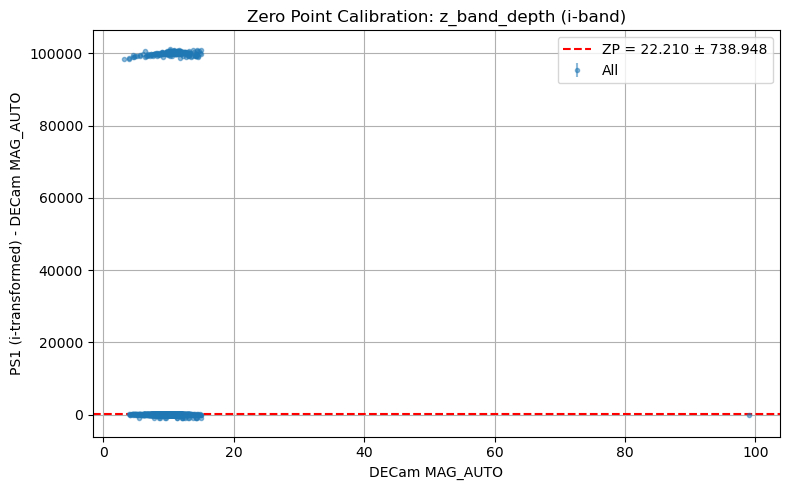

 10%|█         | 1/10 [00:00<00:01,  7.38it/s]

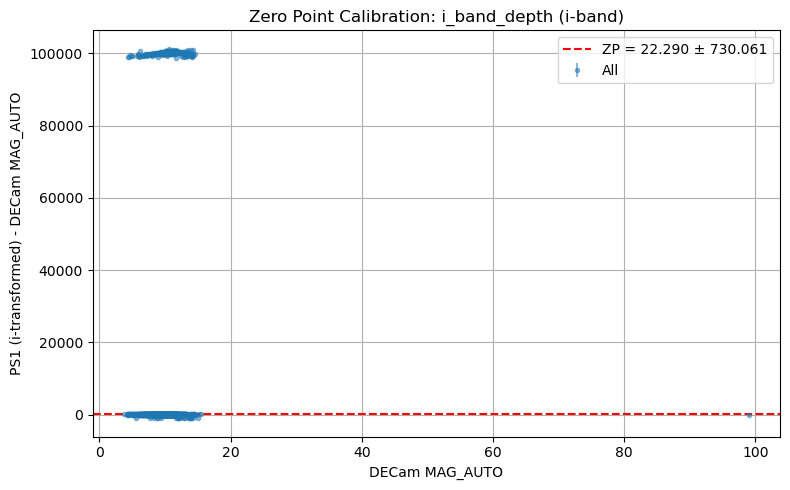

 20%|██        | 2/10 [00:00<00:01,  7.78it/s]

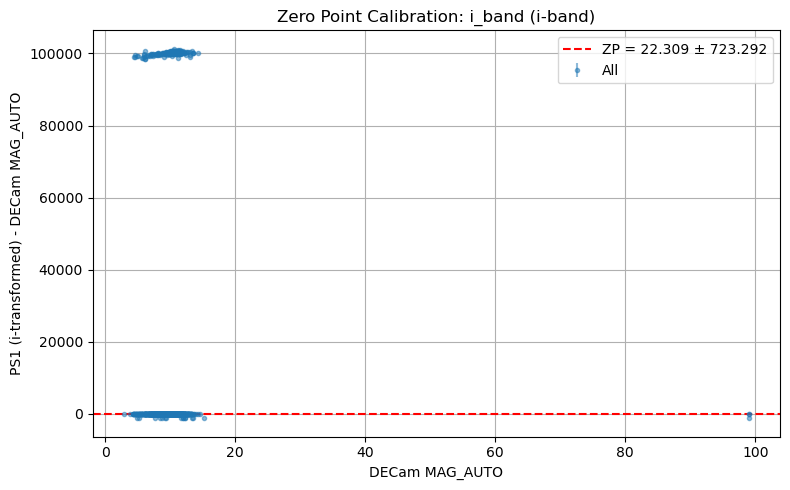

 30%|███       | 3/10 [00:00<00:00,  8.17it/s]

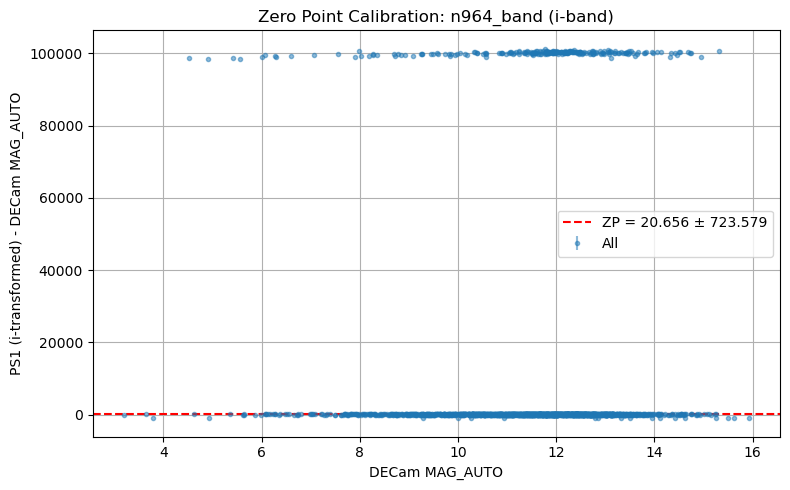

 50%|█████     | 5/10 [00:00<00:00, 11.36it/s]

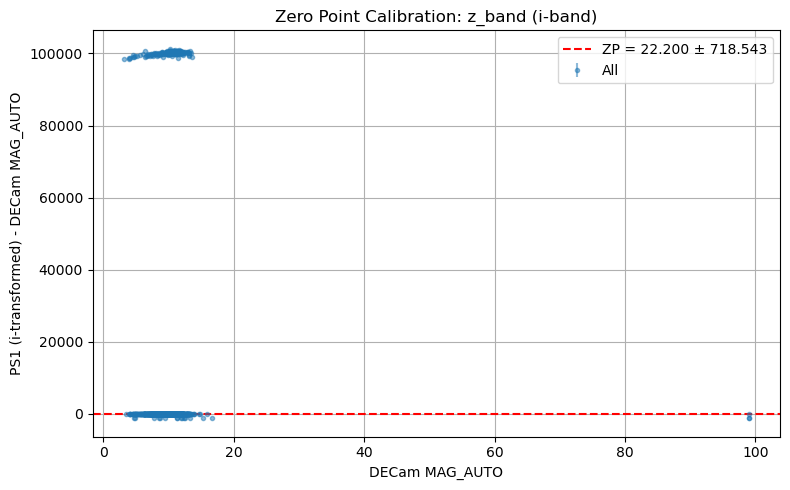

100%|██████████| 10/10 [00:00<00:00, 16.45it/s]


z_band_depth: ZP = 22.210 ± 738.948
i_band_depth: ZP = 22.290 ± 730.061
i_band: ZP = 22.309 ± 723.292
n964_band: ZP = 20.656 ± 723.579
z_band: ZP = 22.200 ± 718.543

=== Processing z-band ===


  0%|          | 0/10 [00:00<?, ?it/s]

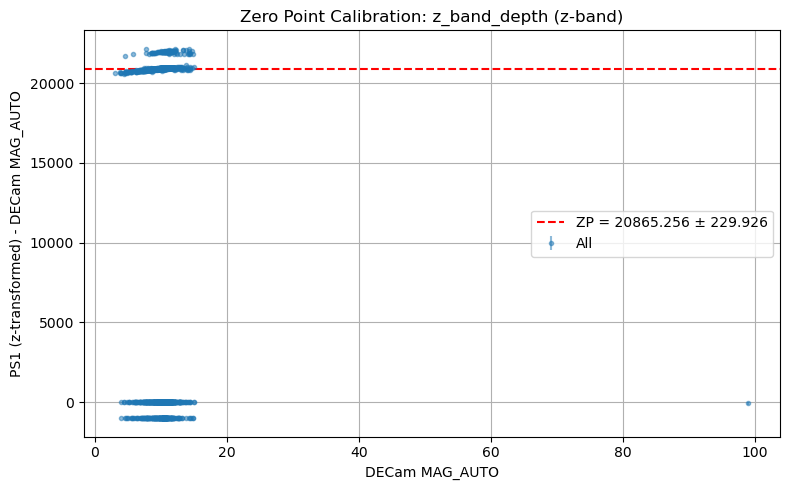

 10%|█         | 1/10 [00:00<00:01,  8.70it/s]

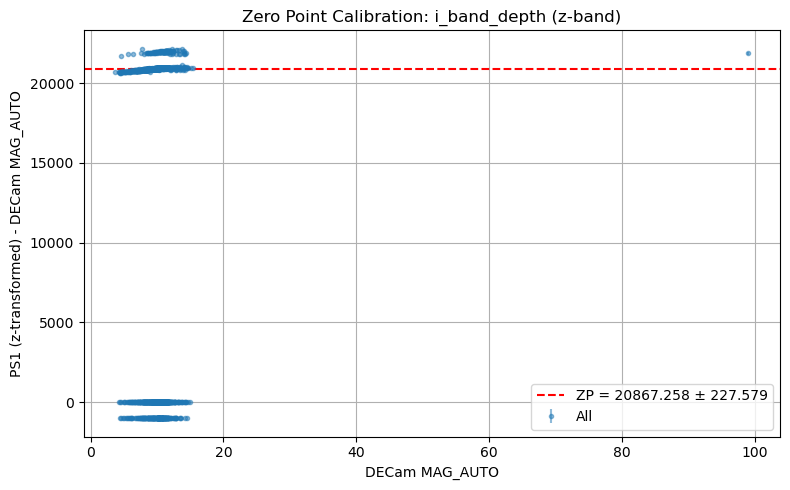

 20%|██        | 2/10 [00:00<00:00,  8.27it/s]

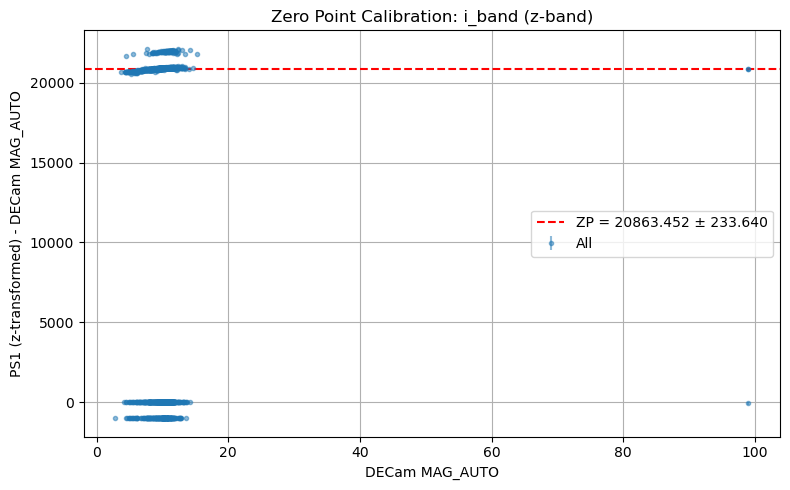

 30%|███       | 3/10 [00:00<00:00,  7.97it/s]

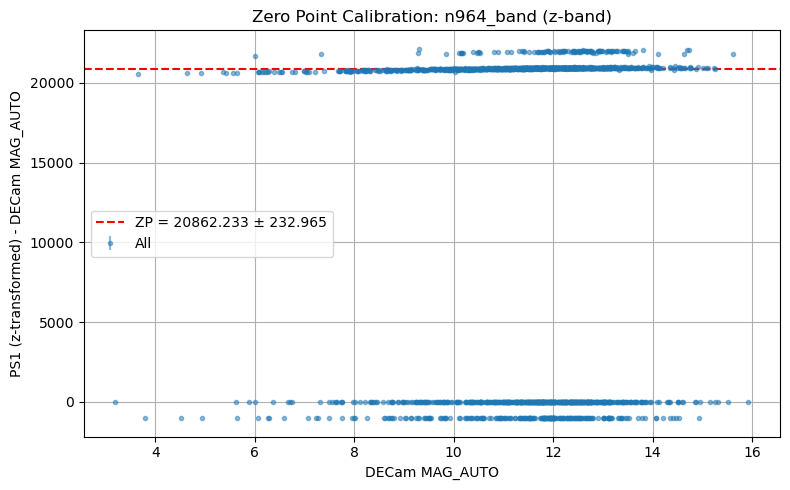

 50%|█████     | 5/10 [00:00<00:00,  6.76it/s]

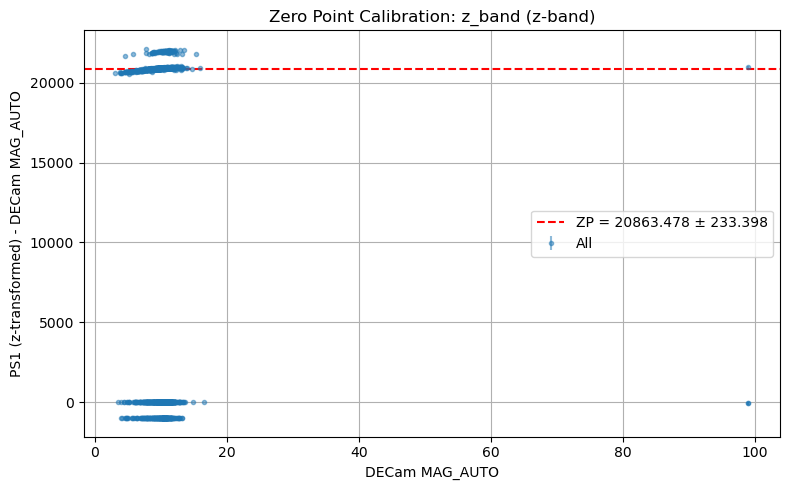

100%|██████████| 10/10 [00:00<00:00, 11.32it/s]

z_band_depth: ZP = 20865.256 ± 229.926
i_band_depth: ZP = 20867.258 ± 227.579
i_band: ZP = 20863.452 ± 233.640
n964_band: ZP = 20862.233 ± 232.965
z_band: ZP = 20863.478 ± 233.398


In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from astropy.coordinates import SkyCoord
import astropy.units as u
from scipy.stats import sigmaclip
from tqdm import tqdm

# Function to read DECam catalog and fix header parsing issue
def read_decam_catalog(filename):
    with open(filename) as f:
        header = f.readline().strip().split(',')
    return pd.read_csv(filename, skiprows=1, names=header)

# Function to read Pan-STARRS catalog (assumed to already be parsed correctly)
def read_ps_catalog(filename):
    return pd.read_csv(filename)

# Function to cross-match catalogs
def crossmatch_catalogs(decam_df, ps_df, max_sep=1.0):
    decam_coords = SkyCoord(ra=decam_df['RA_CORRECTED'].values * u.deg,
                            dec=decam_df['DEC_CORRECTED'].values * u.deg)
    ps_coords = SkyCoord(ra=ps_df['RA_CORRECTED'].values * u.deg,
                         dec=ps_df['DEC_CORRECTED'].values * u.deg)
    
    idx, d2d, _ = decam_coords.match_to_catalog_sky(ps_coords)
    matched = d2d.arcsec < max_sep
    
    decam_matched = decam_df[matched].reset_index(drop=True)
    ps_matched = ps_df.iloc[idx[matched]].reset_index(drop=True)
    
    return decam_matched, ps_matched

# Function to compute color-transformed PS1 mag based on DES DR2 (for i and z bands)
def compute_transformed_ps_mag(ps_df, band):
    if band == "i":
        g, r, i = ps_df["gPSFMag"], ps_df["rPSFMag"], ps_df["iPSFMag"]
        g_r = g - r
        r_i = r - i
        i_des = i + 0.014 - 0.214 * g_r + 0.096 * g_r**2 - 0.011 * r_i
        return i_des
    elif band == "z":
        r, i, z = ps_df["rPSFMag"], ps_df["iPSFMag"], ps_df["zPSFMag"]
        r_i = r - i
        i_z = i - z
        z_des = z + 0.022 - 0.068 * r_i + 0.021 * r_i**2 - 0.005 * i_z
        return z_des
    else:
        raise ValueError("Invalid band: choose 'i' or 'z'")

# Function to compute zero point and plot
def compute_zero_point(decam_df, ps_df, band, output_name):
    if 'MAG_AUTO' not in decam_df.columns or 'MAGERR_AUTO' not in decam_df.columns:
        raise ValueError("DECam catalog missing MAG_AUTO or MAGERR_AUTO columns")
    
    mag_decam = decam_df["MAG_AUTO"].astype(float)
    magerr_decam = decam_df["MAGERR_AUTO"].astype(float)
    mag_ps_transformed = compute_transformed_ps_mag(ps_df, band)

    # Filter valid data
    valid = np.isfinite(mag_decam) & np.isfinite(magerr_decam) & np.isfinite(mag_ps_transformed)
    mag_decam = mag_decam[valid]
    magerr_decam = magerr_decam[valid]
    mag_ps_transformed = mag_ps_transformed[valid]

    delta_mag = mag_ps_transformed - mag_decam

    # Sigma clipping
    clipped, _, _ = sigmaclip(delta_mag, low=3.0, high=3.0)
    zp = np.median(clipped)
    zp_std = np.std(clipped)
    zp_err = zp_std / np.sqrt(len(clipped))

    # Plot
    plt.figure(figsize=(8, 5))
    plt.errorbar(mag_decam, delta_mag, yerr=magerr_decam, fmt='o', ms=3, alpha=0.5, label="All")
    plt.axhline(zp, color='r', linestyle='--', label=f'ZP = {zp:.3f} ± {zp_err:.3f}')
    plt.xlabel("DECam MAG_AUTO")
    plt.ylabel(f"PS1 ({band}-transformed) - DECam MAG_AUTO")
    plt.title(f"Zero Point Calibration: {output_name} ({band}-band)")
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()


    return zp, zp_err

# Main function to loop over all matched file pairs
def process_all_pairs(matched_dir, band):
    results = []
    for name in tqdm(os.listdir(matched_dir)):
        if not name.endswith("_panstarrs_matched.csv"):
            continue

        base_name = name.replace("_panstarrs_matched.csv", "")
        ps_path = os.path.join(matched_dir, name)
        decam_path = os.path.join(matched_dir, f"{base_name}_decam_matched.cat")

        if not os.path.exists(decam_path):
            print(f"Missing DECam file for {base_name}")
            continue

        try:
            decam_df = read_decam_catalog(decam_path)
            ps_df = read_ps_catalog(ps_path)

            # Cross-match to ensure alignment
            decam_matched, ps_matched = crossmatch_catalogs(decam_df, ps_df)

            if decam_matched.empty or ps_matched.empty:
                raise ValueError("Matched catalogs are empty")

            zp, zp_err = compute_zero_point(decam_matched, ps_matched, band, base_name)
            results.append((base_name, zp, zp_err))
        except Exception as e:
            print(f"Error processing {base_name}: {e}")
    return results

# Example usage
matched_dir = "/Users/aishwarya/Documents/Lyman_alpha/CAT/cat/m"

for band in ["i", "z"]:
    print(f"\n=== Processing {band}-band ===")
    results = process_all_pairs(matched_dir, band)
    for name, zp, err in results:
        print(f"{name}: ZP = {zp:.3f} ± {err:.3f}")


# trial 2

In [119]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from astropy.coordinates import SkyCoord
import astropy.units as u
from scipy.stats import sigmaclip
from tqdm import tqdm

# Function to read DECam catalog and fix header parsing issue
def read_decam_catalog(filename):
    with open(filename) as f:
        header = f.readline().strip().split(',')
    return pd.read_csv(filename, skiprows=1, names=header)

# Function to read Pan-STARRS catalog (assumed to already be parsed correctly)
def read_ps_catalog(filename):
    return pd.read_csv(filename)

# Function to cross-match catalogs
def crossmatch_catalogs(decam_df, ps_df, max_sep=1.0):
    decam_coords = SkyCoord(ra=decam_df['RA_CORRECTED'].values * u.deg,
                            dec=decam_df['DEC_CORRECTED'].values * u.deg)
    ps_coords = SkyCoord(ra=ps_df['RA_CORRECTED'].values * u.deg,
                         dec=ps_df['DEC_CORRECTED'].values * u.deg)
    
    idx, d2d, _ = decam_coords.match_to_catalog_sky(ps_coords)
    matched = d2d.arcsec < max_sep
    
    decam_matched = decam_df[matched].reset_index(drop=True)
    ps_matched = ps_df.iloc[idx[matched]].reset_index(drop=True)
    
    return decam_matched, ps_matched

# Function to compute color-transformed PS1 mag based on DES DR2 (for i and z bands)
def compute_transformed_ps_mag(ps_df, band):
    if band == "i":
        g, r, i = ps_df["gPSFMag"], ps_df["rPSFMag"], ps_df["iPSFMag"]
        g_r = g - r
        r_i = r - i
        i_des = i + 0.014 - 0.214 * g_r + 0.096 * g_r**2 - 0.011 * r_i
        return i_des
    elif band == "z":
        r, i, z = ps_df["rPSFMag"], ps_df["iPSFMag"], ps_df["zPSFMag"]
        r_i = r - i
        i_z = i - z
        z_des = z + 0.022 - 0.068 * r_i + 0.021 * r_i**2 - 0.005 * i_z
        return z_des
    else:
        raise ValueError("Invalid band: choose 'i' or 'z'")

# Function to compute zero point and plot
def compute_zero_point(decam_df, ps_df, band, output_name):
    if 'MAG_AUTO' not in decam_df.columns or 'MAGERR_AUTO' not in decam_df.columns:
        raise ValueError("DECam catalog missing MAG_AUTO or MAGERR_AUTO columns")
    
    mag_decam = decam_df["MAG_AUTO"].astype(float)
    magerr_decam = decam_df["MAGERR_AUTO"].astype(float)
    mag_ps_transformed = compute_transformed_ps_mag(ps_df, band)

    # Filter valid data
    valid = np.isfinite(mag_decam) & np.isfinite(magerr_decam) & np.isfinite(mag_ps_transformed)
    mag_decam = mag_decam[valid]
    magerr_decam = magerr_decam[valid]
    mag_ps_transformed = mag_ps_transformed[valid]

    delta_mag = mag_ps_transformed - mag_decam

    # Sigma clipping
    clipped, _, _ = sigmaclip(delta_mag, low=3.0, high=3.0)
    zp = np.median(clipped)
    zp_std = np.std(clipped)
    zp_err = zp_std / np.sqrt(len(clipped))

    # Plot
    plt.figure(figsize=(8, 5))
    plt.errorbar(mag_decam, delta_mag, yerr=magerr_decam, fmt='o', ms=3, alpha=0.5, label="All")
    plt.axhline(zp, color='r', linestyle='--', label=f'ZP = {zp:.3f} ± {zp_err:.3f}')
    plt.xlabel("DECam MAG_AUTO")
    plt.ylabel(f"PS1 ({band}-transformed) - DECam MAG_AUTO")
    plt.title(f"Zero Point Calibration: {output_name} ({band}-band)")
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()


    return zp, zp_err

# Main function to loop over all matched file pairs
def process_all_pairs(matched_dir, band):
    results = []
    for name in tqdm(os.listdir(matched_dir)):
        if not name.endswith(f"_{band}_panstarrs_matched.csv"):
            continue

        base_name = name.replace(f"_{band}_panstarrs_matched.csv", "")
        ps_path = os.path.join(matched_dir, name)
        decam_path = os.path.join(matched_dir, f"{base_name}_{band}_decam_matched.cat")

        if not os.path.exists(decam_path):
            print(f"Missing DECam file for {base_name} ({band}-band)")
            continue

        try:
            decam_df = read_decam_catalog(decam_path)
            ps_df = read_ps_catalog(ps_path)

            # Cross-match to ensure alignment
            decam_matched, ps_matched = crossmatch_catalogs(decam_df, ps_df)

            if decam_matched.empty or ps_matched.empty:
                raise ValueError("Matched catalogs are empty")

            zp, zp_err = compute_zero_point(decam_matched, ps_matched, band, base_name)
            results.append((base_name, zp, zp_err))
        except Exception as e:
            print(f"Error processing {base_name} ({band}-band): {e}")
    return results

# Example usage
matched_dir = "/Users/aishwarya/Documents/Lyman_alpha/CAT/cat/m"

for band in ["i", "z"]:
    print(f"\n=== Processing {band}-band ===")
    results = process_all_pairs(matched_dir, band)
    for name, zp, err in results:
        print(f"{name}: ZP = {zp:.3f} ± {err:.3f}")



=== Processing i-band ===


100%|██████████| 11/11 [00:00<00:00, 114769.51it/s]



=== Processing z-band ===


100%|██████████| 11/11 [00:00<00:00, 77541.75it/s]


In [ ]:
! pip install tqdm


  Using cached tqdm-4.67.1-py3-none-any.whl.metadata (57 kB)
Using cached tqdm-4.67.1-py3-none-any.whl (78 kB)


In [ ]:
import pandas as pd

# Replace with one of your actual Pan-STARRS CSV file paths
panstarrs_file = '/Users/aishwarya/Documents/Lyman_alpha/CAT/cat/m/i_band_panstarrs_matched.csv'

pan = pd.read_csv(panstarrs_file)
print(pan.columns)


Index(['objName', 'objID', 'projectionID', 'skyCellID', 'objInfoFlag',
       'qualityFlag', 'raMean', 'decMean', 'raMeanErr', 'decMeanErr',
       'epochMean', 'posMeanChisq', 'nStackObjectRows', 'nStackDetections',
       'nDetections', 'primaryDetection', 'bestDetection', 'gPSFMag',
       'gPSFMagErr', 'gKronMag', 'gKronMagErr', 'ginfoFlag', 'ginfoFlag2',
       'ginfoFlag3', 'gpsfQf', 'gpsfQfPerfect', 'gPSFFlux', 'gPSFFluxErr',
       'gKronFlux', 'gKronFluxErr', 'gKronRad', 'rPSFMag', 'rPSFMagErr',
       'rKronMag', 'rKronMagErr', 'rinfoFlag', 'rinfoFlag2', 'rinfoFlag3',
       'rpsfQf', 'rpsfQfPerfect', 'rPSFFlux', 'rPSFFluxErr', 'rKronFlux',
       'rKronFluxErr', 'rKronRad', 'iPSFMag', 'iPSFMagErr', 'iKronMag',
       'iKronMagErr', 'iinfoFlag', 'iinfoFlag2', 'iinfoFlag3', 'ipsfQf',
       'ipsfQfPerfect', 'iPSFFlux', 'iPSFFluxErr', 'iKronFlux', 'iKronFluxErr',
       'iKronRad', 'zPSFMag', 'zPSFMagErr', 'zKronMag', 'zKronMagErr',
       'zinfoFlag', 'zinfoFlag2', 'zinfoFlag3

# doing it one by one

In [122]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from astropy.coordinates import SkyCoord
import astropy.units as u
from scipy.stats import sigmaclip

# Read DECam catalog
def read_decam_catalog(filename):
    with open(filename) as f:
        header = f.readline().strip().split(',')
    return pd.read_csv(filename, skiprows=1, names=header)

# Read Pan-STARRS catalog
def read_ps_catalog(filename):
    return pd.read_csv(filename)

# Cross-match catalogs
def crossmatch_catalogs(decam_df, ps_df, max_sep=1.0):
    decam_coords = SkyCoord(ra=decam_df['RA_CORRECTED'].values * u.deg,
                            dec=decam_df['DEC_CORRECTED'].values * u.deg)
    ps_coords = SkyCoord(ra=ps_df['RA_CORRECTED'].values * u.deg,
                         dec=ps_df['DEC_CORRECTED'].values * u.deg)
    
    idx, d2d, _ = decam_coords.match_to_catalog_sky(ps_coords)
    matched = d2d.arcsec < max_sep
    
    decam_matched = decam_df[matched].reset_index(drop=True)
    ps_matched = ps_df.iloc[idx[matched]].reset_index(drop=True)
    
    return decam_matched, ps_matched

# Compute transformed z-band PS1 mag to DECam system (Eq. 2)
def compute_transformed_z(ps_df):
    z_ps1 = ps_df["zPSFMag"]
    r_ps1 = ps_df["rPSFMag"]
    i_ps1 = ps_df["iPSFMag"]
    return z_ps1 - 0.114 * (r_ps1 - i_ps1) - 0.010

# Compute zero point
def compute_zero_point(decam_df, ps_df):
    mag_decam = decam_df["MAG_AUTO"].astype(float)
    magerr_decam = decam_df["MAGERR_AUTO"].astype(float)
    mag_ps_transformed = compute_transformed_z(ps_df)

    valid = np.isfinite(mag_decam) & np.isfinite(magerr_decam) & np.isfinite(mag_ps_transformed)
    mag_decam = mag_decam[valid]
    magerr_decam = magerr_decam[valid]
    mag_ps_transformed = mag_ps_transformed[valid]

    delta_mag = mag_ps_transformed - mag_decam

    clipped, _, _ = sigmaclip(delta_mag, low=3.0, high=3.0)
    zp = np.median(clipped)
    zp_std = np.std(clipped)
    zp_err = zp_std / np.sqrt(len(clipped))

    plt.figure(figsize=(8, 5))
    plt.errorbar(mag_decam, delta_mag, yerr=magerr_decam, fmt='o', ms=3, alpha=0.5, label="All")
    plt.axhline(zp, color='r', linestyle='--', label=f'ZP = {zp:.3f} ± {zp_err:.3f}')
    plt.xlabel("DECam MAG_AUTO")
    plt.ylabel("Transformed PS1 z - DECam MAG_AUTO")
    plt.title("Zero Point Calibration (z-band)")
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()

    return zp, zp_err

# Run for specific files
decam_path = "/Users/aishwarya/Documents/Lyman_alpha/CAT/cat/m/i_band_decam_matched.cat"
ps_path = "/Users/aishwarya/Documents/Lyman_alpha/CAT/cat/m/i_band_panstarrs_matched.csv"

decam_df = read_decam_catalog(decam_path)
ps_df = read_ps_catalog(ps_path)
decam_matched, ps_matched = crossmatch_catalogs(decam_df, ps_df)

if decam_matched.empty or ps_matched.empty:
    print("Matched catalogs are empty")
else:
    zp, zp_err = compute_zero_point(decam_matched, ps_matched)
    print(f"ZP = {zp:.3f} ± {zp_err:.3f}")


ZP = -892.071 ± 10.035


In [125]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import sigmaclip

# Optional: for VS Code Jupyter Notebook
# %matplotlib inline

# Read DECam catalog
def read_decam_catalog(filename):
    with open(filename) as f:
        header = f.readline().strip().split(',')
    return pd.read_csv(filename, skiprows=1, names=header)

# Read Pan-STARRS catalog
def read_ps_catalog(filename):
    return pd.read_csv(filename)

# Compute transformed z-band PS1 mag to DECam system (Eq. 2)
def compute_transformed_z(ps_df):
    z_ps1 = ps_df["zPSFMag"]
    r_ps1 = ps_df["rPSFMag"]
    i_ps1 = ps_df["iPSFMag"]
    return z_ps1 - 0.114 * (r_ps1 - i_ps1) - 0.010

# Compute zero point
def compute_zero_point(decam_df, ps_df):
    mag_decam = decam_df["MAG_AUTO"].astype(float)
    magerr_decam = decam_df["MAGERR_AUTO"].astype(float)
    print(mag_decam)
    mag_ps_transformed = compute_transformed_z(ps_df)

    valid = np.isfinite(mag_decam) & np.isfinite(magerr_decam) & np.isfinite(mag_ps_transformed)
    mag_decam = mag_decam[valid]
    magerr_decam = magerr_decam[valid]
    mag_ps_transformed = mag_ps_transformed[valid]

    delta_mag = mag_ps_transformed - mag_decam

    clipped, _, _ = sigmaclip(delta_mag, low=3.0, high=3.0)
    zp = np.median(clipped)
    zp_std = np.std(clipped)
    zp_err = zp_std / np.sqrt(len(clipped))

    plt.figure(figsize=(8, 5))
    plt.errorbar(mag_decam, delta_mag, yerr=magerr_decam, fmt='o', ms=3, alpha=0.5, label="All")
    plt.axhline(zp, color='r', linestyle='--', label=f'ZP = {zp:.3f} ± {zp_err:.3f}')
    plt.xlabel("DECam MAG_AUTO")
    plt.ylabel("Transformed PS1 z - DECam MAG_AUTO")
    plt.title("Zero Point Calibration (z-band)")
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()

    return zp, zp_err

# Run for specific files (already cross-matched)
decam_path = "/Users/aishwarya/Documents/Lyman_alpha/CAT/cat/m/i_band_decam_matched.cat"
ps_path = "/Users/aishwarya/Documents/Lyman_alpha/CAT/cat/m/i_band_panstarrs_matched.csv"

decam_df = read_decam_catalog(decam_path)
ps_df = read_ps_catalog(ps_path)

if len(decam_df) != len(ps_df):
    print("Warning: Catalog lengths do not match. Ensure row-by-row match.")
else:
    zp, zp_err = compute_zero_point(decam_df, ps_df)
    print(f"ZP = {zp:.3f} ± {zp_err:.3f}")


0       12.5691
1        9.3403
2        6.7383
3        7.3797
4       10.2042
         ...   
2133     5.1953
2134     7.5316
2135     8.0821
2136    10.9761
2137    10.1327
Name: MAG_AUTO, Length: 2138, dtype: float64
ZP = -892.101 ± 9.744
